In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/howonmjeong/soldiers-in-formation/event_meta.csv
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_011.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_013.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_007.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_002.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_006.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_010.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_004.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_005.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_009.jpg
/kaggle/input/datasets/howonmjeong/soldiers-in-formation/images/unit_events/event_001.jpg
/kaggle/input/datasets/howon

In [2]:
%pip install ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
path = '/kaggle/input/datasets/howonmjeong/soldiers-in-formation/'
meta = pd.read_csv(path + 'event_meta.csv')
img_dir = path + 'images/unit_events/'
model = YOLO('yolov8n.pt')

In [4]:
counts = []

for f in meta['filename']:
    r = model.predict(os.path.join(img_dir, f), classes=[0], conf=0.25, verbose=False)[0]
    counts.append(len(r.boxes))

meta['person_count'] = counts

result = meta.groupby('unit_name')['person_count'].agg(total_count='sum', avg_count='mean').reset_index()

print(result)

  unit_name  total_count  avg_count
0       1대대           23   5.750000
1       2대대           25   4.166667
2       3대대           17   5.666667


/tmp/ipykernel_16/939042598.py:18: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


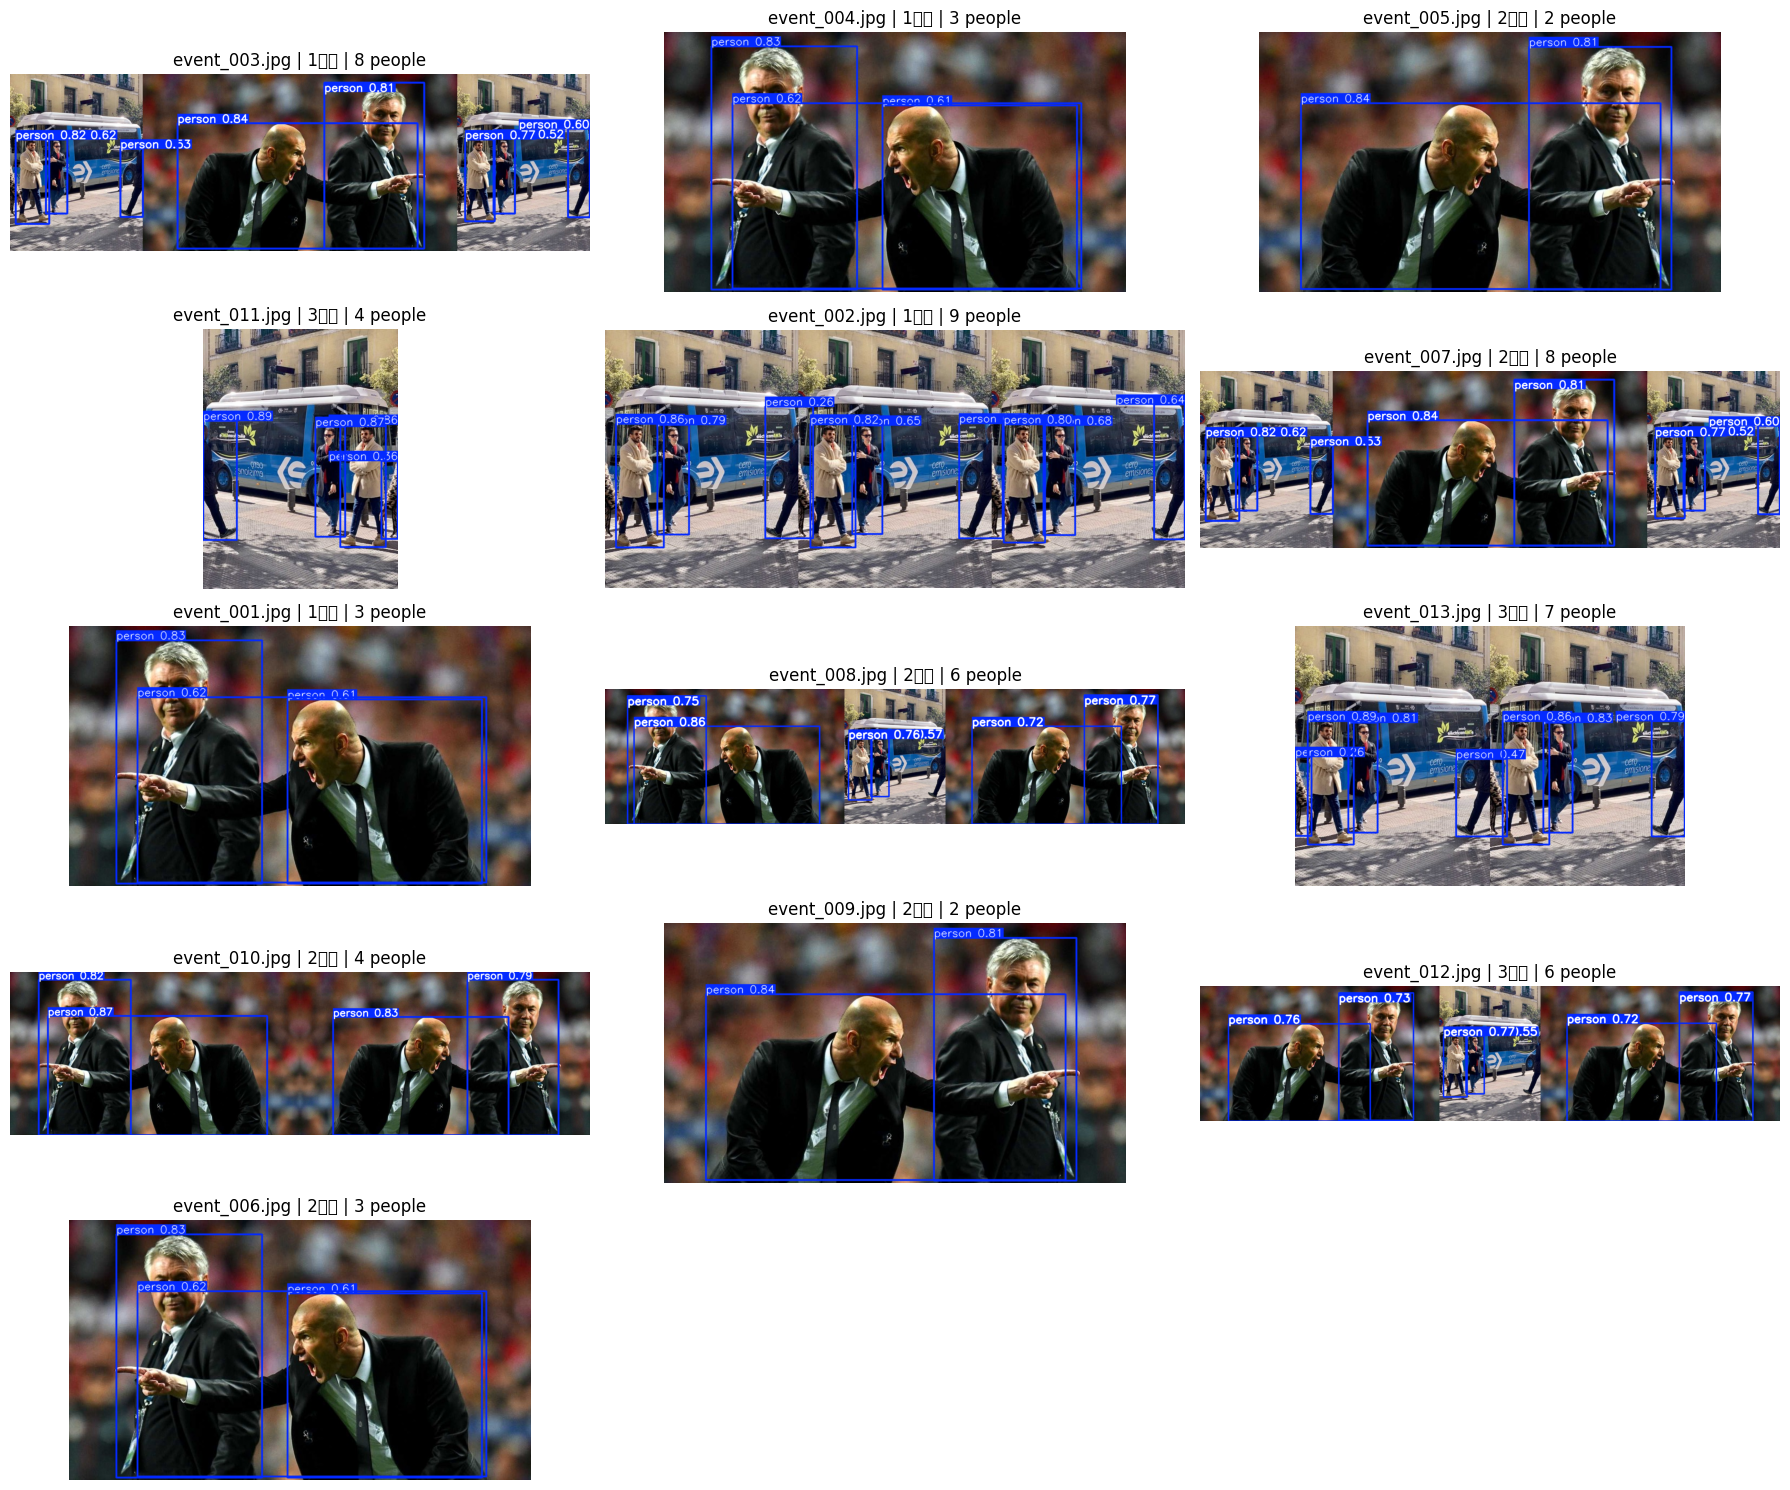

In [5]:
import matplotlib.pyplot as plt
import math

n = len(meta)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 3))

for ax, (_, row) in zip(axes.flat, meta.iterrows()):
    r = model.predict(os.path.join(img_dir, row['filename']), classes=[0], conf=0.25, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1])                     # BGR → RGB
    ax.set_title(f"{row['filename']} | {row['unit_name']} | {len(r.boxes)} people")
    ax.axis('off')

for ax in axes.flat[n:]:                               # 남는 빈 칸 숨기기
    ax.axis('off')

plt.tight_layout()
plt.show()